[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JMasr/audio-ml-tutorials/blob/main/es/mfcc-plp-from-scratch.ipynb)

Autor: José Manuel Ramírez Sánchez · https://jmramirez.engineer

# MFCC y PLP desde cero: los rasgos acústicos clásicos, reconstruidos en NumPy

Antes de los modelos *end-to-end*, todo reconocedor de voz empezaba con la misma pregunta: ¿qué números describen 25 ms de voz? Dos respuestas dominaron durante tres décadas:

- **MFCC** (Davis y Mermelstein, 1980): un banco de filtros en escala Mel, un logaritmo y una DCT.
- **PLP** (Hermansky, 1990): un espectro auditivo en escala Bark, ponderación de igual sonoridad, compresión con raíz cúbica y un modelo todo-polos (LPC). **RASTA** (Hermansky y Morgan, 1994) añade un filtro paso banda en el tiempo que elimina los efectos lentos del canal.

Ambos eran los *front ends* estándar de Kaldi (Povey et al., 2011). Hoy la DCT y el modelo LPC han desaparecido, pero la primera mitad del pipeline sobrevive: Whisper y la mayoría de los modelos de ASR actuales consumen bancos de filtros log-Mel. Los notebooks hermanos ajustan uno de ellos: [Whisper con Optuna y MLflow](whisper-optuna-mlflow.ipynb) y [PEFT y LoRA en Whisper](whisper-peft-lora.ipynb).

Este notebook:

1. Carga una locución de LibriSpeech.
2. Construye los MFCC paso a paso, con una figura por paso.
3. Construye PLP y RASTA-PLP de la misma forma.
4. Comprueba las implementaciones contra `librosa` y `spafe`.
5. Ejecuta un pequeño experimento con ruido (blanco y *babble*, de 20 a 0 dB de SNR).
6. Muestra que la entrada de Whisper es el espectrograma log-Mel del paso 2.

Todo se ejecuta en CPU en bastante menos de un minuto (unos 20 s en un portátil).

> **Dónde empezó esta serie.** La tesis de ingeniería y el primer artículo del autor compararon exactamente estos dos rasgos dentro de Kaldi: J. M. Ramírez, A. R. Montalvo y J. R. Calvo, "Evaluación de Rasgos Acústicos para el Reconocimiento Automático del Habla en Escenarios Ruidosos usando Kaldi", *RIELAC* 40(3):51–71, 2019 ([artículo](https://rielac.cujae.edu.cu/index.php/rieac/article/view/743)).
>
> MFCC frente a RASTA-PLP en habla espontánea en español (TC-STAR, conjunto de prueba de 3 h 36 min), con 40 filtros Mel o Bark, 12 coeficientes cepstrales y los mismos deltas, LDA, MLLT y CMVN para ambos. Ocho pares de sistemas fueron desde HMM-GMM (mono, tri1–tri3), pasando por SGMM (y SGMM+MMI), hasta DNN y una combinación de sistemas (comb). Se añadieron ruidos reales de interiores y exteriores de la base DEMAND (18 grabaciones) con la herramienta FaNT, a SNR aleatorias de 5–15 y 15–25 dB.
>
> | Escenario | WER comb, MFCC (%) | WER comb, RASTA-PLP (%) |
> |---|---|---|
> | Limpio | 20.77 | 21.05 |
> | IN_DOOR 15–25 dB | 22.24 | 22.85 |
> | OUT_DOOR 15–25 dB | 21.71 | 22.86 |
> | IN_DOOR 5–15 dB | 28.82 | 31.89 |
> | OUT_DOOR 5–15 dB | 30.73 | 34.35 |
>
> En voz limpia ambos quedaron a menos de 1 % absoluto en todos los sistemas salvo tri2 (27,95 % MFCC frente a 22,86 % PLP). La ventaja de MFCC creció con el ruido, hasta tri2 en OUT_DOOR 5–15 dB (45,26 % frente a 52,86 %). En cambio, RASTA-PLP decodificó más rápido en todos los sistemas (p. ej. tri3: 3:16:03 frente a 2:25:17). Conclusión: MFCC fue más robusto con ruido, ambos fueron similares con poco ruido y PLP redujo el tiempo de procesamiento.

Instala las dependencias:

```bash
pip install numpy scipy matplotlib datasets soundfile librosa spafe transformers==4.57.6
```

In [1]:
import io
import json
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from datasets import Audio, load_dataset
from scipy.fft import dct
from scipy.signal import freqz, lfilter, lfilter_zi

T0 = time.perf_counter()
SEED = 17
DATASET_ID = 'hf-internal-testing/librispeech_asr_dummy'
DATASET_CONFIG = 'clean'
DATASET_SPLIT = 'validation'
SAMPLE_RATE = 16_000

# Front-end parameters (Kaldi-style defaults).
PRE_EMPHASIS = 0.97
FRAME_MS, HOP_MS = 25, 10
FRAME_LEN = SAMPLE_RATE * FRAME_MS // 1000  # 400 samples
HOP_LEN = SAMPLE_RATE * HOP_MS // 1000  # 160 samples
N_FFT = 512
N_MELS = 40
N_CEPS = 13
LIFTER = 22
LPC_ORDER = 12

# Small, consistent, grayscale-friendly figures.
plt.rcParams.update({
    'figure.figsize': (7.0, 2.4),
    'figure.dpi': 90,
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '0.9',
    'lines.linewidth': 1.2,
})
FIGSIZE_WIDE = (7.0, 2.4)
IMAGE_CMAP = matplotlib.colormaps['magma'].resampled(32)  # 32 levels keep the PNGs small
FIGSIZE_ROW = (9.0, 2.6)

.../site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Una locución de voz real

El audio es la primera locución de `hf-internal-testing/librispeech_asr_dummy` (config `clean`, split `validation`), un fragmento de 73 locuciones de **LibriSpeech** (Panayotov et al., 2015, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)): inglés leído a 16 kHz. La columna de audio se carga con `decode=False` y los bytes FLAC se decodifican con `soundfile`, porque las versiones recientes de `datasets` necesitan el paquete adicional `torchcodec` para decodificar el audio por su cuenta. Las demás locuciones se usan más adelante para construir ruido *babble*.

73 utterances; using 1272-128104-0000: 5.86 s
text: mister quilter is the apostle of the middle classes and we are glad to welcome his gospel


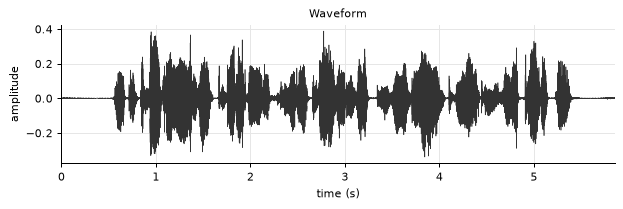

In [2]:
def decode_flac(audio_field: dict) -> np.ndarray:
    """Decode the raw FLAC bytes stored in the dataset into a float64 waveform."""
    waveform, sample_rate = sf.read(io.BytesIO(audio_field['bytes']), dtype='float64')
    if sample_rate != SAMPLE_RATE:
        raise ValueError(f'Expected {SAMPLE_RATE} Hz audio, got {sample_rate} Hz')
    return waveform


# decode=False returns the encoded bytes, so soundfile decodes them and torchcodec is not needed.
raw_dataset = load_dataset(DATASET_ID, DATASET_CONFIG, split=DATASET_SPLIT)
raw_dataset = raw_dataset.cast_column('audio', Audio(decode=False))
records = [
    {'id': row['id'], 'chapter_id': int(row['chapter_id']), 'text': row['text'], 'audio': decode_flac(row['audio'])}
    for row in raw_dataset
]

signal = records[0]['audio']
time_axis = np.arange(len(signal)) / SAMPLE_RATE
print(f"{len(records)} utterances; using {records[0]['id']}: {len(signal) / SAMPLE_RATE:.2f} s")
print(f"text: {records[0]['text'].lower()}")

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(time_axis, signal, color='0.2', linewidth=0.5)
ax.set(xlabel='time (s)', ylabel='amplitude', title='Waveform', xlim=(0, time_axis[-1]))
fig.tight_layout()
plt.show()

## 2. MFCC, paso a paso

Los parámetros son los valores por defecto habituales al estilo Kaldi: preénfasis 0,97, tramas de 25 ms cada 10 ms, ventana de Hamming, FFT de 512 puntos, 40 filtros Mel, 13 coeficientes cepstrales (c0 a c12) y *lifter* 22.

### 2.1 Preénfasis

La voz sonora pierde unos 6 dB por octava. Un filtro paso alto de primer orden, y[n] = x[n] − 0,97·x[n−1], aplana el espectro para que las bandas altas no queden sepultadas bajo las bajas.

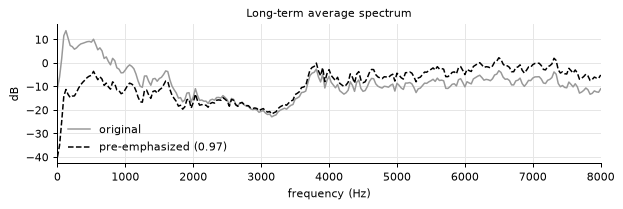

In [3]:
def pre_emphasis(x: np.ndarray, coeff: float = PRE_EMPHASIS) -> np.ndarray:
    """First-order high-pass y[n] = x[n] - coeff * x[n-1]; boosts the high frequencies."""
    return np.append(x[0], x[1:] - coeff * x[:-1])


emphasized = pre_emphasis(signal)


def average_spectrum_db(x: np.ndarray) -> np.ndarray:
    """Long-term average power spectrum in dB (only used for the plot below)."""
    frames = np.lib.stride_tricks.sliding_window_view(x, N_FFT)[::N_FFT]
    return 10 * np.log10(np.mean(np.abs(np.fft.rfft(frames * np.hanning(N_FFT))) ** 2, axis=0) + 1e-12)


freqs_hz = np.fft.rfftfreq(N_FFT, 1 / SAMPLE_RATE)
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(freqs_hz, average_spectrum_db(signal), color='0.6', label='original')
ax.plot(freqs_hz, average_spectrum_db(emphasized), color='0.0', linestyle='--', label='pre-emphasized (0.97)')
ax.set(xlabel='frequency (Hz)', ylabel='dB', title='Long-term average spectrum', xlim=(0, SAMPLE_RATE / 2))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 2.2 Segmentación en tramas y enventanado

La voz solo es aproximadamente estacionaria durante unas decenas de milisegundos, así que la señal se corta en tramas de 25 ms (400 muestras) cada 10 ms (160 muestras). Cada trama se multiplica por una ventana de Hamming, que suaviza sus bordes y reduce la fuga espectral.

frames: (584, 400)  (25 ms windows every 10 ms)


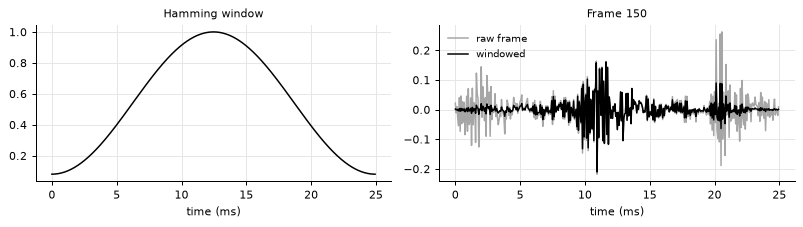

In [4]:
def frame_signal(x: np.ndarray, frame_len: int = FRAME_LEN, hop_len: int = HOP_LEN) -> np.ndarray:
    """Slice the signal into overlapping frames, shape (n_frames, frame_len). No padding: the tail is dropped."""
    if len(x) < frame_len:
        raise ValueError('Signal shorter than one frame')
    return np.lib.stride_tricks.sliding_window_view(x, frame_len)[::hop_len].copy()


def hamming_window(n: int = FRAME_LEN) -> np.ndarray:
    """Symmetric Hamming window 0.54 - 0.46 cos(2 pi k / (n - 1))."""
    return 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(n) / (n - 1))


frames = frame_signal(emphasized)
windowed = frames * hamming_window()
print(f'frames: {frames.shape}  ({FRAME_MS} ms windows every {HOP_MS} ms)')

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_ROW)
frame_idx = 150
ms = np.arange(FRAME_LEN) / SAMPLE_RATE * 1000
axes[0].plot(ms, hamming_window(), color='0.0')
axes[0].set(xlabel='time (ms)', title='Hamming window')
axes[1].plot(ms, frames[frame_idx], color='0.65', label='raw frame')
axes[1].plot(ms, windowed[frame_idx], color='0.0', label='windowed')
axes[1].set(xlabel='time (ms)', title=f'Frame {frame_idx}')
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

### 2.3 Espectro de potencia

Cada trama de 400 muestras se rellena con ceros hasta 512 puntos y se transforma con la FFT; el módulo al cuadrado de los 257 bins de frecuencia no negativa es el espectro de potencia (separación entre bins de 31,25 Hz).

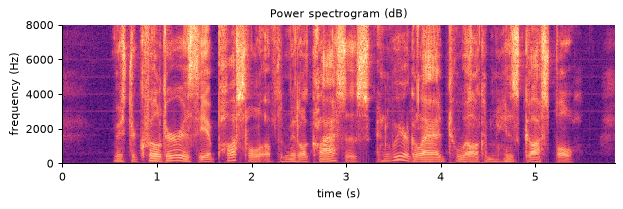

In [5]:
def power_spectrum(windowed_frames: np.ndarray, n_fft: int = N_FFT) -> np.ndarray:
    """|FFT|^2 of each zero-padded frame, shape (n_frames, n_fft // 2 + 1)."""
    return np.abs(np.fft.rfft(windowed_frames, n=n_fft, axis=1)) ** 2


power = power_spectrum(windowed)
frame_times = (np.arange(len(power)) * HOP_LEN + FRAME_LEN / 2) / SAMPLE_RATE


def show_image(
    ax: plt.Axes, matrix: np.ndarray, title: str, ylabel: str,
    extent_y: tuple[float, float] | None = None, clim: tuple[float, float] | None = None, t0: float = 0.0,
) -> None:
    """Plot a (frames x bins) matrix with time on the x axis; t0 is the time of the first row."""
    y0, y1 = extent_y if extent_y else (0, matrix.shape[1])
    t1 = t0 + len(matrix) * HOP_MS / 1000
    ax.imshow(matrix.T, origin='lower', aspect='auto', extent=(t0, t1, y0, y1), interpolation='nearest', clim=clim, cmap=IMAGE_CMAP)
    ax.set(title=title, xlabel='time (s)', ylabel=ylabel)
    ax.grid(False)


fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
show_image(ax, 10 * np.log10(power + 1e-10), 'Power spectrogram (dB)', 'frequency (Hz)', (0, SAMPLE_RATE / 2))
fig.tight_layout()
plt.show()

### 2.4 Banco de filtros Mel

El oído resuelve las frecuencias bajas con mucha más finura que las altas. La escala Mel, mel(f) = 1127·ln(1 + f/700), es aproximadamente lineal por debajo de 1 kHz y logarítmica por encima. Cuarenta filtros triangulares con centros equiespaciados en Mel (bordes de 0 Hz a 8 kHz) integran el espectro de potencia en 40 energías de banda: bandas estrechas en frecuencias bajas y anchas en las altas. Aquí los triángulos son lineales en Hz entre bordes espaciados en Mel, con pico 1 y sin normalización de área.

Mel filterbank: (40, 257), Mel energies: (584, 40)


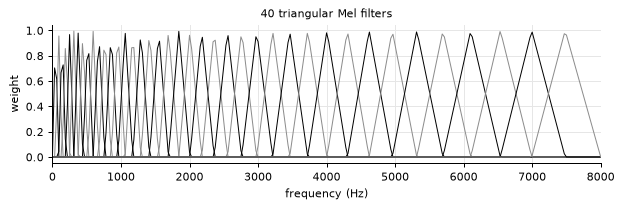

In [6]:
def hz_to_mel(f: np.ndarray | float) -> np.ndarray:
    """HTK/Kaldi Mel scale: 1127 ln(1 + f / 700)."""
    return 1127.0 * np.log1p(np.asarray(f) / 700.0)


def mel_to_hz(m: np.ndarray | float) -> np.ndarray:
    """Inverse of hz_to_mel."""
    return 700.0 * np.expm1(np.asarray(m) / 1127.0)


def mel_filterbank(
    n_mels: int = N_MELS, n_fft: int = N_FFT, sr: int = SAMPLE_RATE, f_min: float = 0.0, f_max: float | None = None
) -> np.ndarray:
    """Triangular filters equally spaced on the Mel scale, shape (n_mels, n_fft // 2 + 1), peak 1, no area norm."""
    f_max = f_max or sr / 2
    edges_hz = mel_to_hz(np.linspace(hz_to_mel(f_min), hz_to_mel(f_max), n_mels + 2))
    bins_hz = np.fft.rfftfreq(n_fft, 1 / sr)
    lower, center, upper = edges_hz[:-2, None], edges_hz[1:-1, None], edges_hz[2:, None]
    rising = (bins_hz - lower) / (center - lower)
    falling = (upper - bins_hz) / (upper - center)
    return np.maximum(0.0, np.minimum(rising, falling))


mel_fb = mel_filterbank()
mel_energies = power @ mel_fb.T
print(f'Mel filterbank: {mel_fb.shape}, Mel energies: {mel_energies.shape}')

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for k, weights in enumerate(mel_fb):
    ax.plot(freqs_hz, weights, color='0.0' if k % 2 == 0 else '0.55', linewidth=0.8)
ax.set(xlabel='frequency (Hz)', ylabel='weight', title=f'{N_MELS} triangular Mel filters', xlim=(0, SAMPLE_RATE / 2))
fig.tight_layout()
plt.show()

### 2.5 Logaritmo, DCT y *liftering*

- **Logaritmo.** La percepción de la sonoridad es aproximadamente logarítmica, y el logaritmo convierte un canal multiplicativo (micrófono, sala) en un desplazamiento aditivo.
- **DCT-II (ortonormal).** Las bandas log-Mel vecinas están muy correladas. La DCT las decorrela y concentra la envolvente espectral suave en los primeros coeficientes; quedarse con 13 (c0 a c12) descarta la estructura fina, sobre todo los armónicos del tono. Los rasgos decorrelados encajaban con las gaussianas de covarianza diagonal de los sistemas HMM-GMM.
- **Liftering.** Los coeficientes cepstrales altos tienen valores más pequeños. El *lifter* de HTK/Kaldi multiplica c_n por 1 + (L/2)·sin(πn/L), con L = 22, para llevarlos a un rango comparable.

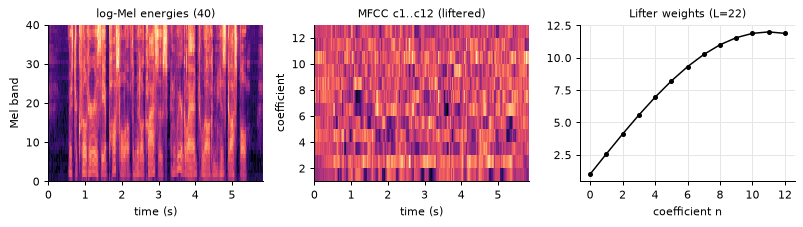

In [7]:
def log_compress(energies: np.ndarray, floor: float = 1e-10) -> np.ndarray:
    """Natural log with a floor so silent bands do not produce -inf."""
    return np.log(np.maximum(energies, floor))


def cepstrum(log_energies: np.ndarray, n_ceps: int = N_CEPS) -> np.ndarray:
    """Orthonormal DCT-II over the band axis, keeping the first n_ceps coefficients (c0 included)."""
    return dct(log_energies, type=2, norm='ortho', axis=1)[:, :n_ceps]


def lifter(ceps: np.ndarray, L: int = LIFTER) -> np.ndarray:
    """HTK/Kaldi sinusoidal liftering: c_n * (1 + L/2 sin(pi n / L)), n = 0..N-1."""
    n = np.arange(ceps.shape[1])
    return ceps * (1 + (L / 2) * np.sin(np.pi * n / L))


log_mel = log_compress(mel_energies)
mfcc_raw = cepstrum(log_mel)
mfcc_lift = lifter(mfcc_raw)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_ROW)
show_image(axes[0], log_mel, 'log-Mel energies (40)', 'Mel band')
show_image(axes[1], mfcc_lift[:, 1:], 'MFCC c1..c12 (liftered)', 'coefficient', extent_y=(1, 13))
axes[2].plot(np.arange(N_CEPS), 1 + (LIFTER / 2) * np.sin(np.pi * np.arange(N_CEPS) / LIFTER), 'ko-', markersize=3)
axes[2].set(xlabel='coefficient n', title=f'Lifter weights (L={LIFTER})', xticks=range(0, N_CEPS, 2))
fig.tight_layout()
plt.show()

### 2.6 CMVN, deltas y delta-deltas

**CMVN** (normalización de media y varianza cepstral) resta la media de cada coeficiente en la locución y divide por su desviación típica. Restar la media cancela cualquier canal fijo, porque un canal convolutivo es una constante aditiva en el dominio log/cepstral. Los **deltas** estiman la pendiente de cada coeficiente en ±2 tramas por regresión lineal, y los **delta-deltas** aplican el mismo operador otra vez. Estáticos + Δ + ΔΔ forman el clásico vector de 39 dimensiones. La celda siguiente también agrupa los pasos 2.1–2.5 en una única función `mfcc()`, que se usa en el resto del notebook.

MFCC + deltas + delta-deltas: (584, 39)  (the classic 39-dimensional vector)


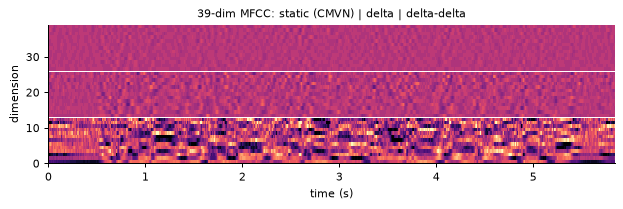

In [8]:
def cmvn(features: np.ndarray) -> np.ndarray:
    """Per-utterance cepstral mean and variance normalization (each coefficient: zero mean, unit variance)."""
    return (features - features.mean(axis=0)) / (features.std(axis=0) + 1e-10)


def deltas(features: np.ndarray, width: int = 2) -> np.ndarray:
    """Regression deltas: sum_n n (c[t+n] - c[t-n]) / (2 sum_n n^2), edges replicated."""
    padded = np.pad(features, ((width, width), (0, 0)), mode='edge')
    denom = 2 * sum(n * n for n in range(1, width + 1))
    T = len(features)
    return sum(n * (padded[width + n : width + n + T] - padded[width - n : width - n + T]) for n in range(1, width + 1)) / denom


def mfcc(x: np.ndarray, n_mels: int = N_MELS) -> np.ndarray:
    """Full MFCC front end: pre-emphasis, frames, Hamming, power spectrum, Mel, log, DCT, lifter (no CMVN)."""
    pow_spec = power_spectrum(frame_signal(pre_emphasis(x)) * hamming_window())
    return lifter(cepstrum(log_compress(pow_spec @ mel_filterbank(n_mels).T)))


mfcc_static = cmvn(mfcc(signal))
assert np.allclose(mfcc(signal), mfcc_lift)
mfcc_full = np.hstack([mfcc_static, deltas(mfcc_static), deltas(deltas(mfcc_static))])
print(f'MFCC + deltas + delta-deltas: {mfcc_full.shape}  (the classic 39-dimensional vector)')

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
show_image(ax, mfcc_full, '39-dim MFCC: static (CMVN) | delta | delta-delta', 'dimension', clim=(-2.5, 2.5))
for boundary in (N_CEPS, 2 * N_CEPS):
    ax.axhline(boundary, color='white', linewidth=0.8)
fig.tight_layout()
plt.show()

## 3. PLP y RASTA-PLP

PLP parte del mismo espectro de potencia, pero modela la audición con más detalle y resume cada trama con un modelo todo-polos. Siguiendo a Hermansky (1990), no hay preénfasis: la curva de igual sonoridad cumple ese papel.

### 3.1 Bandas críticas Bark

La frecuencia se transforma a la escala Bark, Ω(f) = 6·asinh(f/600), y el espectro se integra con la curva de enmascaramiento de banda crítica de Hermansky: plana en ±0,5 Bark alrededor del centro, con una caída de 10 dB por Bark en los 2,5 Bark por debajo y de 25 dB por Bark en los 1,3 Bark por encima. Los centros están separados 1 Bark desde 0 Bark hasta Nyquist (19,7 Bark a 16 kHz), lo que da 21 bandas. El artículo de arriba usó 40 filtros para ambos rasgos; 21 es el espaciado original de Hermansky. La figura pone ambos bancos de filtros en el mismo eje.

Bark filterbank: (21, 257) (centres 0.99 Bark apart)


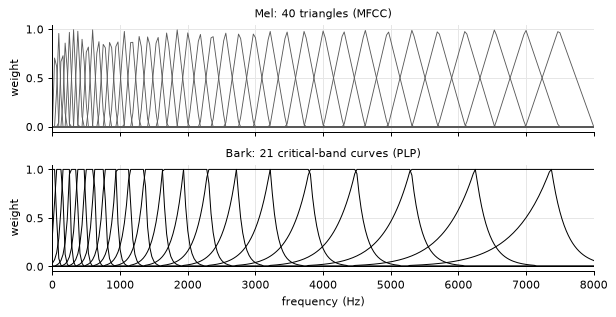

In [9]:
def hz_to_bark(f: np.ndarray | float) -> np.ndarray:
    """Hermansky (1990) Bark warping: 6 asinh(f / 600)."""
    return 6.0 * np.arcsinh(np.asarray(f) / 600.0)


def critical_band_curve(delta_bark: np.ndarray) -> np.ndarray:
    """Hermansky (1990) masking curve psi(z), z = centre - bin (Bark): 2.5 Bark below the centre, 1.3 above."""
    z = np.asarray(delta_bark, dtype=float)
    weights = np.zeros_like(z)
    weights = np.where((z >= -1.3) & (z <= -0.5), 10 ** (2.5 * (z + 0.5)), weights)
    weights = np.where((z > -0.5) & (z < 0.5), 1.0, weights)
    weights = np.where((z >= 0.5) & (z <= 2.5), 10 ** (-1.0 * (z - 0.5)), weights)
    return weights


def bark_filterbank(n_fft: int = N_FFT, sr: int = SAMPLE_RATE, n_bands: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Critical-band filters with centres ~1 Bark apart from 0 Bark to Nyquist. Returns (weights, centres_hz)."""
    nyquist_bark = float(hz_to_bark(sr / 2))
    n_bands = n_bands or int(np.ceil(nyquist_bark)) + 1
    centres_bark = np.linspace(0.0, nyquist_bark, n_bands)
    bins_bark = hz_to_bark(np.fft.rfftfreq(n_fft, 1 / sr))
    weights = critical_band_curve(centres_bark[:, None] - bins_bark[None, :])
    centres_hz = 600.0 * np.sinh(centres_bark / 6.0)
    return weights, centres_hz


bark_fb, bark_centres_hz = bark_filterbank()
print(f'Bark filterbank: {bark_fb.shape} (centres {np.diff(hz_to_bark(bark_centres_hz))[0]:.2f} Bark apart)')

fig, axes = plt.subplots(2, 1, figsize=(7.0, 3.6), sharex=True)
for weights in mel_fb:
    axes[0].plot(freqs_hz, weights, color='0.35', linewidth=0.7)
axes[0].set(ylabel='weight', title=f'Mel: {N_MELS} triangles (MFCC)')
for weights in bark_fb:
    axes[1].plot(freqs_hz, weights, color='0.0', linewidth=0.8)
axes[1].set(xlabel='frequency (Hz)', ylabel='weight', title=f'Bark: {len(bark_fb)} critical-band curves (PLP)', xlim=(0, SAMPLE_RATE / 2))
fig.tight_layout()
plt.show()

### 3.2 Preénfasis de igual sonoridad y compresión intensidad-sonoridad

Cada banda se pondera con la aproximación de Hermansky a la sensibilidad del oído a 40 dB, E(ω) = (ω² + 56,8·10⁶)·ω⁴ / [(ω² + 6,3·10⁶)²·(ω² + 0,38·10⁹)·(ω⁶ + 9,58·10²⁶)], ω = 2πf, donde el último factor modela la caída por encima de 5 kHz. Después, una raíz cúbica aproxima la ley de potencia entre intensidad y sonoridad percibida; hace el papel del logaritmo de MFCC, pero comprime menos. La primera y la última banda no son fiables y se sustituyen por copias de sus vecinas, como en el método original.

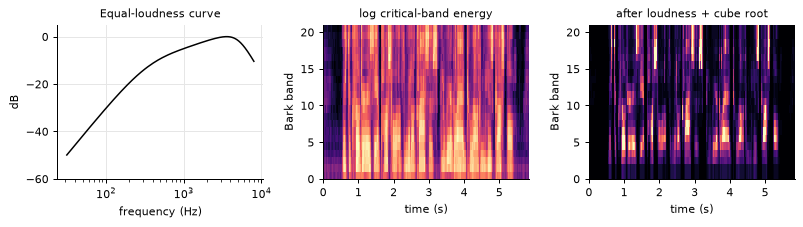

In [10]:
def equal_loudness(centres_hz: np.ndarray) -> np.ndarray:
    """Hermansky (1990) equal-loudness curve E(w), w = 2 pi f, including the term for Nyquist > 5 kHz."""
    w2 = (2 * np.pi * np.asarray(centres_hz)) ** 2
    return ((w2 + 56.8e6) * w2**2) / ((w2 + 6.3e6) ** 2 * (w2 + 0.38e9) * (w2**3 + 9.58e26))


def loudness(band_energies: np.ndarray, centres_hz: np.ndarray) -> np.ndarray:
    """Equal-loudness pre-emphasis, cube-root compression, and copy of the unreliable edge bands (Hermansky 1990)."""
    eql = equal_loudness(centres_hz)
    compressed = (band_energies * (eql / eql.max())) ** (1.0 / 3.0)
    compressed[:, 0] = compressed[:, 1]
    compressed[:, -1] = compressed[:, -2]
    return compressed


band_energies = power_spectrum(frame_signal(signal) * hamming_window()) @ bark_fb.T  # PLP: no pre-emphasis
auditory = loudness(band_energies, bark_centres_hz)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_ROW)
eql_db = 10 * np.log10(equal_loudness(freqs_hz[1:]) / equal_loudness(bark_centres_hz).max())
axes[0].semilogx(freqs_hz[1:], eql_db, color='0.0')
axes[0].set(xlabel='frequency (Hz)', ylabel='dB', title='Equal-loudness curve', ylim=(-60, 5))
show_image(axes[1], np.log(band_energies + 1e-10), 'log critical-band energy', 'Bark band')
show_image(axes[2], auditory, 'after loudness + cube root', 'Bark band', clim=(0, np.percentile(auditory, 99)))
fig.tight_layout()
plt.show()

### 3.3 Modelo todo-polos: autocorrelación, Levinson-Durbin y cepstrum

El espectro auditivo se trata como un espectro de potencia: su DFT inversa (tras reflejarlo para hacerlo par) da los retardos de autocorrelación r₀…r₁₂. Levinson-Durbin resuelve las ecuaciones normales de orden 12 en O(p²) y devuelve el predictor A(z) = 1 + a₁z⁻¹ + … + a₁₂z⁻¹² y el error de predicción. El espectro del modelo, error/|A(e^{jω})|², es una envolvente suave que conserva los picos de los formantes. Por último, la recursión estándar c₀ = ln(error), cₙ = −aₙ − Σₖ (k/n)·cₖ·aₙ₋ₖ lo convierte en 13 coeficientes cepstrales. La celda comprueba la recursión contra un cepstrum calculado por fuerza bruta con la FFT del espectro del modelo.

max |recursion - FFT cepstrum| = 4.44e-16


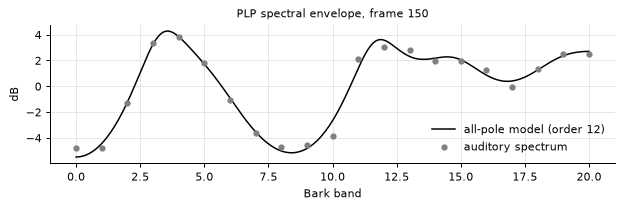

In [11]:
def autocorrelation_from_spectrum(auditory: np.ndarray, order: int = LPC_ORDER) -> np.ndarray:
    """Inverse DFT of the (real, even) auditory spectrum -> first order+1 autocorrelation lags per frame."""
    symmetric = np.hstack([auditory, auditory[:, -2:0:-1]])
    return np.fft.ifft(symmetric, axis=1).real[:, : order + 1]


def levinson_durbin(r: np.ndarray, order: int = LPC_ORDER) -> tuple[np.ndarray, np.ndarray]:
    """Vectorized Levinson-Durbin over frames. Returns A(z) = 1 + a1 z^-1 + ... (n_frames, order+1) and error."""
    n_frames = r.shape[0]
    a = np.zeros((n_frames, order + 1))
    a[:, 0] = 1.0
    error = r[:, 0].copy()
    for i in range(1, order + 1):
        k = -(r[:, i] + np.sum(a[:, 1:i] * r[:, i - 1 : 0 : -1], axis=1)) / error
        a[:, 1:i] = a[:, 1:i] + k[:, None] * a[:, i - 1 : 0 : -1]
        a[:, i] = k
        error = error * (1.0 - k**2)
    return a, error


def lpc_to_cepstrum(a: np.ndarray, error: np.ndarray, n_ceps: int = N_CEPS) -> np.ndarray:
    """Cepstrum of the all-pole power spectrum error / |A|^2: c0 = ln(error), c_n = -a_n - sum_k (k/n) c_k a_(n-k)."""
    order = a.shape[1] - 1
    c = np.zeros((a.shape[0], n_ceps))
    c[:, 0] = np.log(error)
    for n in range(1, n_ceps):
        acc = -a[:, n] if n <= order else np.zeros(a.shape[0])
        for k in range(max(1, n - order), n):
            acc = acc - (k / n) * c[:, k] * a[:, n - k]
        c[:, n] = acc
    return c


r = autocorrelation_from_spectrum(auditory)
lpc_coeffs, lpc_error = levinson_durbin(r)
plp_manual = lpc_to_cepstrum(lpc_coeffs, lpc_error)

# Self-check: the recursion must equal the real cepstrum of ln(error / |A(e^jw)|^2), computed by brute-force FFT.
n_check = 4096
model_log_spec = np.log(lpc_error[:, None]) - 2 * np.log(np.abs(np.fft.fft(lpc_coeffs, n_check, axis=1)))
brute_force = np.fft.ifft(model_log_spec, axis=1).real[:, :N_CEPS]
print(f'max |recursion - FFT cepstrum| = {np.max(np.abs(plp_manual - brute_force)):.2e}')

frame_idx = 150
w = np.linspace(0, np.pi, 256)
model = lpc_error[frame_idx] / np.abs(np.polyval(lpc_coeffs[frame_idx][::-1], np.exp(-1j * w))) ** 2
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(np.linspace(0, len(auditory[0]) - 1, 256), 10 * np.log10(model), color='0.0', label=f'all-pole model (order {LPC_ORDER})')
ax.plot(np.arange(auditory.shape[1]), 10 * np.log10(auditory[frame_idx]), 'o', color='0.5', markersize=4, label='auditory spectrum')
ax.set(xlabel='Bark band', ylabel='dB', title=f'PLP spectral envelope, frame {frame_idx}')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 3.4 RASTA-PLP

Un canal fijo (micrófono, línea telefónica) multiplica el espectro, así que en el dominio logarítmico de bandas críticas se convierte en un desplazamiento que cambia mucho más despacio que las modulaciones de 2–16 Hz de sílabas y fonemas. RASTA (Hermansky y Morgan, 1994) filtra en el tiempo la trayectoria logarítmica de cada banda con el paso banda H(z) = 0,1·(2 + z⁻¹ − z⁻³ − 2z⁻⁴)/(1 − 0,98z⁻¹), que elimina esas componentes lentas, y después vuelve al dominio lineal antes de los pasos de sonoridad. Aquí el filtro es causal (se omite el adelanto z⁴ de la fórmula original) y su estado arranca en la primera trama. La celda agrupa toda la cadena en `plp(x, rasta=...)` y muestra los tres flujos de rasgos lado a lado sobre el mismo segmento de 2 s.

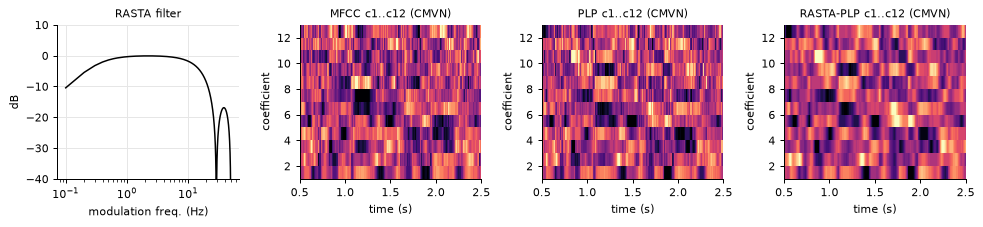

In [12]:
RASTA_NUM = 0.1 * np.array([2.0, 1.0, 0.0, -1.0, -2.0])
RASTA_DEN = np.array([1.0, -0.98])  # Hermansky & Morgan (1994); rastamat and spafe use a 0.94 pole


def rasta_filter(log_bands: np.ndarray) -> np.ndarray:
    """Band-pass IIR filter along time on each log critical-band trajectory (causal; the z^4 advance is dropped)."""
    zi = lfilter_zi(RASTA_NUM, RASTA_DEN)
    return np.stack(
        [lfilter(RASTA_NUM, RASTA_DEN, band, zi=zi * band[0])[0] for band in log_bands.T], axis=1
    )


def plp(x: np.ndarray, rasta: bool = False) -> np.ndarray:
    """PLP (or RASTA-PLP) cepstra: power spectrum -> Bark bands -> [RASTA] -> loudness -> LPC -> cepstrum."""
    pow_spec = power_spectrum(frame_signal(x) * hamming_window())
    bands = pow_spec @ bark_fb.T
    if rasta:
        bands = np.exp(rasta_filter(np.log(np.maximum(bands, 1e-10))))
    a, err = levinson_durbin(autocorrelation_from_spectrum(loudness(bands, bark_centres_hz)))
    return lpc_to_cepstrum(a, err)


assert np.allclose(plp(signal), plp_manual)
plp_static = cmvn(plp(signal))
rasta_static = cmvn(plp(signal, rasta=True))

mod_freqs = np.linspace(0.1, 50, 500)
_, response = freqz(RASTA_NUM, RASTA_DEN, worN=mod_freqs, fs=1000 / HOP_MS)
fig, axes = plt.subplots(1, 4, figsize=(11.0, 2.6))
axes[0].semilogx(mod_freqs, 20 * np.log10(np.abs(response) + 1e-12), color='0.0')
axes[0].set(xlabel='modulation freq. (Hz)', ylabel='dB', title='RASTA filter', ylim=(-40, 10))
segment = slice(50, 250)  # 2 s, so the coefficient trajectories are visible
for ax, feats, name in zip(axes[1:], (mfcc_static, plp_static, rasta_static), ('MFCC', 'PLP', 'RASTA-PLP')):
    show_image(ax, feats[segment, 1:], f'{name} c1..c12 (CMVN)', 'coefficient', extent_y=(1, 13), clim=(-2.5, 2.5), t0=0.5)
fig.tight_layout()
plt.show()

## 4. Verificación contra implementaciones de referencia

### 4.1 MFCC frente a `librosa`

`librosa` reproduce exactamente el pipeline una vez que se igualan todas las convenciones: la misma señal con preénfasis, la misma ventana de Hamming simétrica, sin centrado, la fórmula Mel de HTK, triángulos de pico 1 (`norm=None`), logaritmo natural y DCT-II ortonormal. Un detalle: con `win_length < n_fft`, librosa centra la ventana de 400 muestras dentro de cada trama de 512, así que la señal se rellena con 56 muestras a cada lado para alinear las tramas. La única diferencia que queda es el *lifter*, que se compara aparte al final de la celda.

In [13]:
import librosa

# Match every convention: same pre-emphasized signal, symmetric Hamming (400) centred in a 512-point frame,
# no centering/padding, HTK Mel formula, peak-1 triangles (norm=None), natural log, orthonormal DCT-II.
pad = (N_FFT - FRAME_LEN) // 2  # librosa centres the 400-sample window inside each 512-sample frame
mel_librosa = librosa.feature.melspectrogram(
    y=np.pad(emphasized, (pad, pad)), sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LEN, win_length=FRAME_LEN,
    window=hamming_window(), center=False, power=2.0, n_mels=N_MELS, htk=True, norm=None, fmin=0.0, fmax=SAMPLE_RATE / 2,
).T
mfcc_librosa = librosa.feature.mfcc(S=np.log(np.maximum(mel_librosa, 1e-10)).T, n_mfcc=N_CEPS, dct_type=2, norm='ortho').T
ours = cepstrum(log_mel)  # unliftered, to isolate the lifter convention below

print(f'frames: ours {ours.shape[0]}, librosa {mfcc_librosa.shape[0]}')
print(f'Mel filterbank max abs diff: {np.abs(librosa.filters.mel(sr=SAMPLE_RATE, n_fft=N_FFT, n_mels=N_MELS, htk=True, norm=None) - mel_fb).max():.2e}')
rel_err = np.abs(ours - mfcc_librosa).max(axis=0) / np.abs(mfcc_librosa).max(axis=0)
corr = [np.corrcoef(ours[:, k], mfcc_librosa[:, k])[0, 1] for k in range(N_CEPS)]
print('per-coefficient max relative error:', np.array2string(rel_err, precision=1, formatter={'float_kind': lambda v: f'{v:.1e}'}))
print(f'per-coefficient correlation: min {min(corr):.6f}')
print(f'deltas vs librosa.feature.delta: max abs diff {np.abs(deltas(mfcc_static) - librosa.feature.delta(mfcc_static.T, width=5, mode="nearest").T).max():.2e}')

# Liftering: librosa weights coefficient n with sin(pi (n+1) / L); HTK/Kaldi use sin(pi n / L).
lift_librosa = librosa.feature.mfcc(S=np.log(np.maximum(mel_librosa, 1e-10)).T, n_mfcc=N_CEPS, lifter=LIFTER).T
ratio = np.median(lift_librosa / mfcc_lift, axis=0)
print('lifter weight ratio librosa/ours per coefficient:', np.round(ratio, 3))

frames: ours 584, librosa 584
Mel filterbank max abs diff: 2.97e-08
per-coefficient max relative error: [3.3e-10 7.2e-10 2.4e-09 2.9e-09 2.5e-09 2.8e-09 3.6e-09 2.8e-09 8.8e-09
 5.9e-09 5.9e-09 6.2e-09 6.3e-09]
per-coefficient correlation: min 1.000000
deltas vs librosa.feature.delta: max abs diff 6.66e-16
lifter weight ratio librosa/ours per coefficient: [2.565 1.598 1.359 1.247 1.181 1.135 1.101 1.073 1.05  1.029 1.009 0.991
 0.972]


Los cepstros coinciden con un error relativo de unos 10⁻⁸ (librosa usa un banco de filtros en float32 y aquí se usa float64), con correlación 1,000000 en todos los coeficientes, y los deltas coinciden con `librosa.feature.delta` a precisión de máquina. El *lifter* es una diferencia de convención real, no un error: librosa pondera el coeficiente n con sin(π(n+1)/L), mientras que HTK y Kaldi usan sin(πn/L), así que los pesos de librosa están desplazados un índice (la razón mostrada arriba). Tras CMVN, cualquier escala por coeficiente, *lifter* incluido, se cancela.

### 4.2 PLP y RASTA-PLP frente a `spafe`

`spafe` (0.3.3) es la implementación de PLP en Python más accesible. La celda siguiente la compara con la nuestra en tres etapas, pasando nuestro propio banco de filtros a spafe para que solo puedan diferir los pasos posteriores.

In [14]:
from scipy.linalg import solve_toeplitz
from spafe.fbanks.bark_fbanks import bark_filter_banks
from spafe.features.rplp import plp as spafe_plp, rplp as spafe_rplp
from spafe.utils.preprocessing import SlidingWindow, framing, windowing

# 0) Internal check of our Levinson-Durbin against a generic Toeplitz solver.
direct = np.stack([solve_toeplitz(rr[:-1], -rr[1:]) for rr in r])
print(f'Levinson-Durbin vs scipy solve_toeplitz: max abs diff {np.abs(lpc_coeffs[:, 1:] - direct).max():.2e}')

# 1) Framing, window and critical-band integration: identical up to spafe's 1/n_fft power scale.
spafe_frames, frame_len = framing(signal, fs=SAMPLE_RATE, win_len=FRAME_MS / 1000, win_hop=HOP_MS / 1000)
spafe_power = np.abs(np.fft.fft(windowing(spafe_frames, frame_len, 'hamming'), N_FFT))[:, : N_FFT // 2 + 1] ** 2 / N_FFT
print(f'critical-band energies vs spafe steps: max rel diff {np.abs(spafe_power @ bark_fb.T / (band_energies / N_FFT) - 1).max():.2e}')

# 2) spafe's Bark filterbank = the same masking curve applied the other way round (steep side below the centre),
#    sampled at bin frequencies k * fs / (n_fft + 1) and zeroed outside the first/last centre bins.
spafe_fb, spafe_centres_bark = bark_filter_banks(nfilts=len(bark_fb), nfft=N_FFT, fs=SAMPLE_RATE)
spafe_grid_bark = hz_to_bark(np.arange(N_FFT // 2 + 1) * SAMPLE_RATE / (N_FFT + 1))
mirrored = critical_band_curve(spafe_grid_bark[None, :] - spafe_centres_bark[:, None])
edge_bins = np.floor((N_FFT + 1) * 600 * np.sinh(spafe_centres_bark[[0, -1]] / 6) / SAMPLE_RATE).astype(int)
mirrored[:, : edge_bins[0]] = 0
mirrored[:, edge_bins[1] :] = 0
print(f'spafe Bark filterbank vs ours: max abs diff {np.abs(spafe_fb - bark_fb).max():.2f} | '
      f'vs our curve mirrored on its grid: {np.abs(spafe_fb - mirrored).max():.1e}')

# 3) End-to-end cepstra, with matched framing, window, FFT size and *our* filterbank passed in.
window = SlidingWindow(win_len=FRAME_MS / 1000, win_hop=HOP_MS / 1000, win_type='hamming')
common = dict(fs=SAMPLE_RATE, order=N_CEPS, pre_emph=False, window=window, nfilts=len(bark_fb), nfft=N_FFT, fbanks=bark_fb)
for name, ours_feats, theirs in (
    ('PLP', plp(signal), spafe_plp(signal, **common)),
    ('RASTA-PLP', plp(signal, rasta=True), spafe_rplp(signal, **common)),
):
    corr = [np.corrcoef(ours_feats[:, k], theirs[:, k])[0, 1] for k in range(1, N_CEPS)]
    print(f'{name} vs spafe, per-coefficient correlation c1..c12: '
          f'median {np.median(corr):.2f} (min {np.min(corr):.2f}, max {np.max(corr):.2f})')

Levinson-Durbin vs scipy solve_toeplitz: max abs diff 1.36e-15
critical-band energies vs spafe steps: max rel diff 4.31e-14
spafe Bark filterbank vs ours: max abs diff 1.00 | vs our curve mirrored on its grid: 1.1e-16


PLP vs spafe, per-coefficient correlation c1..c12: median -0.07 (min -0.13, max 0.26)
RASTA-PLP vs spafe, per-coefficient correlation c1..c12: median -0.04 (min -0.17, max 0.19)


**Cómo leer el resultado de spafe.** Hasta las energías de banda crítica ambas implementaciones son idénticas (salvo la escala 1/n_fft de spafe). El banco de filtros Bark propio de spafe usa la misma transformación y la misma curva de enmascaramiento, pero reflejada: el lado abrupto queda por debajo del centro en vez de por encima. Nuestra orientación sigue la ecuación de Hermansky y la adaptación `rastamat` de Ellis del código original (filtro que se extiende 2,5 Bark por debajo del centro y 1,3 Bark por encima).

Los cepstros finales no coinciden (correlaciones cercanas a cero), y forzar la coincidencia supondría copiar decisiones que difieren de Hermansky (1990). En el código fuente de spafe 0.3.3: la función de igual sonoridad se evalúa sobre las *energías* de banda en lugar de sobre las frecuencias centrales; la DFT inversa se aplica al vector de bandas rellenado con ceros hasta 512 puntos en lugar de al espectro reflejado; el paso LPC vuelve a calcular la autocorrelación de esa secuencia en lugar de usarla como autocorrelación; la recursión LPC-cepstrum multiplica por c_m en lugar de c_k; y en `rplp` el filtro RASTA recorre las bandas dentro de cada trama en lugar del tiempo. Por eso nuestro PLP se apoya en comprobaciones internas: una reproducción exacta del banco de filtros, Levinson-Durbin frente a un resolvedor genérico de Toeplitz (≈10⁻¹⁵) y la recursión cepstral frente a un cepstrum por fuerza bruta con la FFT (≈10⁻¹⁶).

## 5. Un pequeño experimento con ruido

**Montaje.** Diez locuciones limpias del capítulo 128104 (todas de menos de 12 s, 68 s en total) se mezclan con (a) ruido blanco gaussiano y (b) *babble* construido sumando al mismo nivel 5 locuciones largas de los otros dos capítulos, a SNR de 20, 15, 10, 5 y 0 dB (medida sobre la locución completa). El dataset tiene un solo hablante, así que este *babble* es interferencia del mismo locutor, más difícil de separar del objetivo que una multitud de voces distintas.

**Métrica.** Para cada rasgo (MFCC, PLP, RASTA-PLP; 13 coeficientes estáticos, c0 incluido, todos con CMVN) la distorsión es la diferencia RMS entre los rasgos limpios y ruidosos normalizados con CMVN, promediada sobre tramas y coeficientes, y después sobre locuciones. Tras CMVN cada coeficiente se mide en unidades de su propia desviación típica, así que los números son comparables entre rasgos cuyas escalas originales difieren en órdenes de magnitud; dos rasgos sin relación darían en torno a √2 ≈ 1,41. La alternativa era una distancia coseno, pero ignora cuánto se desplaza cada trama en su propia dirección, y una distancia euclídea sin CMVN premiaría sin más al rasgo con la escala original más pequeña.

In [15]:
rng = np.random.default_rng(SEED)
SNRS_DB = [20, 15, 10, 5, 0]
N_TARGETS, N_BABBLE_TALKERS = 10, 5

# Clean targets: the first 10 utterances under 12 s of chapter 128104. Babble: 5 utterances from other chapters.
targets = [r['audio'] for r in records if r['chapter_id'] == 128104 and len(r['audio']) < 12 * SAMPLE_RATE][:N_TARGETS]
babble_sources = [r['audio'] for r in records if r['chapter_id'] != 128104 and len(r['audio']) > 10 * SAMPLE_RATE][:N_BABBLE_TALKERS]


def rms(x: np.ndarray) -> float:
    """Root mean square amplitude."""
    return float(np.sqrt(np.mean(x**2)))


def make_babble(length: int, sources: list[np.ndarray], rng: np.random.Generator) -> np.ndarray:
    """Sum equal-level talkers, each tiled and started at a random offset."""
    babble = np.zeros(length)
    for src in sources:
        tiled = np.tile(src / rms(src), int(np.ceil((length + len(src)) / len(src))))
        start = rng.integers(0, len(src))
        babble += tiled[start : start + length]
    return babble


def add_noise(clean: np.ndarray, noise: np.ndarray, snr_db: float) -> np.ndarray:
    """Scale noise so that 10 log10(P_clean / P_noise) = snr_db over the whole utterance, then add it."""
    return clean + noise * (rms(clean) / rms(noise)) / (10 ** (snr_db / 20))


def distortion(clean_feats: np.ndarray, noisy_feats: np.ndarray) -> float:
    """RMS difference between CMVN-normalized clean and noisy features (units: clean standard deviations)."""
    return float(np.sqrt(np.mean((cmvn(clean_feats) - cmvn(noisy_feats)) ** 2)))


FEATURES = {'MFCC': mfcc, 'PLP': plp, 'RASTA-PLP': lambda x: plp(x, rasta=True)}
noises = {
    'white': [rng.standard_normal(len(t)) for t in targets],
    'babble': [make_babble(len(t), babble_sources, rng) for t in targets],
}
print(f'{len(targets)} targets ({sum(map(len, targets)) / SAMPLE_RATE:.0f} s of speech); babble = {len(babble_sources)} talkers')

10 targets (68 s of speech); babble = 5 talkers


noise experiment: 4.2 s

noise   feature         20 dB     15 dB     10 dB      5 dB      0 dB
white   MFCC            0.714     0.816     0.916     1.010     1.098
white   PLP             0.730     0.839     0.945     1.044     1.131
white   RASTA-PLP       0.696     0.804     0.909     1.009     1.097
babble  MFCC            0.613     0.715     0.826     0.945     1.065
babble  PLP             0.622     0.720     0.830     0.948     1.068
babble  RASTA-PLP       0.598     0.694     0.803     0.923     1.047
white   MFCC < PLP        in 10/10, 10/10, 10/10, 10/10, 10/10 utterances
white   MFCC < RASTA-PLP  in 1/10, 2/10, 4/10, 5/10, 7/10 utterances
babble  MFCC < PLP        in 7/10, 6/10, 8/10, 7/10, 6/10 utterances
babble  MFCC < RASTA-PLP  in 3/10, 2/10, 2/10, 2/10, 2/10 utterances


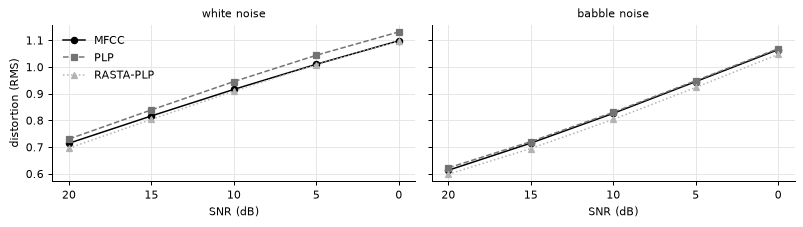

In [16]:
t_start = time.perf_counter()
clean_feats = {name: [fn(t) for t in targets] for name, fn in FEATURES.items()}
results = {noise: {name: [] for name in FEATURES} for noise in noises}
per_utt = {noise: {name: [] for name in FEATURES} for noise in noises}
for noise_name, noise_list in noises.items():
    for snr in SNRS_DB:
        noisy = [add_noise(t, n, snr) for t, n in zip(targets, noise_list)]
        for name, fn in FEATURES.items():
            scores = [distortion(c, fn(x)) for c, x in zip(clean_feats[name], noisy)]
            results[noise_name][name].append(float(np.mean(scores)))
            per_utt[noise_name][name].append(scores)
print(f'noise experiment: {time.perf_counter() - t_start:.1f} s\n')

header = f"{'noise':<8}{'feature':<11}" + ''.join(f'{s:>7} dB' for s in SNRS_DB)
print(header)
for noise_name in noises:
    for name in FEATURES:
        print(f'{noise_name:<8}{name:<11}' + ''.join(f'{v:>10.3f}' for v in results[noise_name][name]))

# Paired view: in how many of the 10 utterances is MFCC less distorted than each PLP variant?
for noise_name in noises:
    for other in ('PLP', 'RASTA-PLP'):
        wins = [int(np.sum(np.array(m) < np.array(o))) for m, o in zip(per_utt[noise_name]['MFCC'], per_utt[noise_name][other])]
        print(f'{noise_name:<8}MFCC < {other:<10} in ' + ', '.join(f'{w}/{len(targets)}' for w in wins) + ' utterances')

styles = {'MFCC': ('0.0', '-', 'o'), 'PLP': ('0.45', '--', 's'), 'RASTA-PLP': ('0.7', ':', '^')}
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_ROW, sharey=True)
for ax, noise_name in zip(axes, noises):
    for name, (color, ls, marker) in styles.items():
        ax.plot(SNRS_DB, results[noise_name][name], color=color, linestyle=ls, marker=marker, markersize=5, label=name)
    ax.set(xlabel='SNR (dB)', title=f'{noise_name} noise', xticks=SNRS_DB)
    ax.invert_xaxis()
axes[0].set_ylabel('distortion (RMS)')
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

**Qué dicen los números.** Los tres rasgos se degradan casi en paralelo: de 20 a 0 dB la distorsión de cada uno sube unos 0,4 (blanco) a 0,45 (*babble*), mientras que la diferencia entre dos rasgos cualesquiera es como mucho 0,036 (menos del 5 %). PLP simple está algo más distorsionado que MFCC, de forma sistemática con ruido blanco (MFCC es menor en 10 de 10 locuciones en todas las SNR) y solo débilmente con *babble* (de 6 a 8 de 10). RASTA-PLP es el menos distorsionado de los tres con ambos ruidos, aunque con ruido blanco su margen sobre MFCC desaparece a 5 y 0 dB.

**Comparación con el artículo.** El artículo encontró MFCC más robusto que RASTA-PLP en WER, con una diferencia que crecía al bajar la SNR. Aquí MFCC supera a PLP simple, pero RASTA-PLP queda ligeramente por delante de MFCC, el orden contrario al del artículo para ese par. No es una contradicción, porque esto no es una reproducción de los experimentos en Kaldi: **la distorsión de rasgos no es WER**. No hay modelo acústico, ni deltas, LDA o MLLT; el corpus es otro (inglés leído en lugar de habla espontánea en español), el ruido es sintético en lugar de grabaciones DEMAND, y la implementación y el número de filtros son distintos. Una razón plausible del resultado de RASTA es que su polo lento suaviza la trayectoria de cada coeficiente, lo que reduce las diferencias trama a trama entre la versión limpia y la ruidosa, pero también puede difuminar detalle que un reconocedor necesita; este experimento no puede separar ambos efectos. El resumen honesto es que, medidos así, los tres *front ends* son aproximadamente igual de frágiles, y diferencias de unos pocos puntos porcentuales en distorsión dicen poco sobre cuál daría el menor WER.

## 6. Puente al ASR moderno: la entrada de Whisper es el paso 2.4

`WhisperFeatureExtractor` para `openai/whisper-tiny` calcula 80 bins log-Mel con ventanas de 25 ms (n_fft = 400) cada 10 ms, rellena o recorta el audio a 30 s, aplica log10, limita el rango dinámico a 8 (80 dB) por debajo del máximo y reescala con (x + 4)/4. La celda lo reconstruye con las funciones de la sección 2 (80 bandas en vez de 40, sin preénfasis, tramas centradas en múltiplos del salto) y compara.

Whisper: 80 Mel bins, n_fft 400 (25 ms), hop 160 (10 ms), padded to 30 s
correlation of the two log-Mel images: 0.938


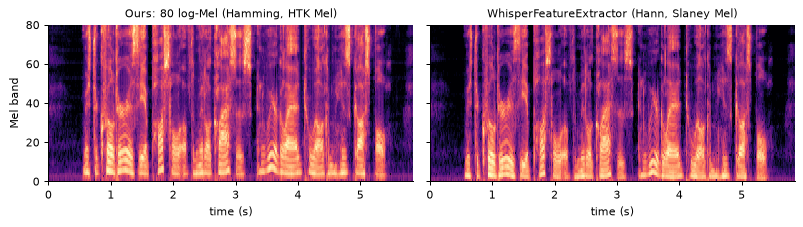

In [17]:
from transformers import WhisperFeatureExtractor

whisper_fe = WhisperFeatureExtractor.from_pretrained('openai/whisper-tiny')
print(f'Whisper: {whisper_fe.feature_size} Mel bins, n_fft {whisper_fe.n_fft} ({whisper_fe.n_fft / SAMPLE_RATE * 1000:.0f} ms), '
      f'hop {whisper_fe.hop_length} ({whisper_fe.hop_length / SAMPLE_RATE * 1000:.0f} ms), padded to {whisper_fe.chunk_length} s')

whisper_logmel = whisper_fe(signal.astype(np.float32), sampling_rate=SAMPLE_RATE, return_tensors='np').input_features[0].T
n_frames = len(signal) // HOP_LEN
whisper_logmel = whisper_logmel[:n_frames]  # drop the 30 s zero padding

# Our step-2 pipeline with Whisper's settings: 80 bands, no pre-emphasis, log10, same dynamic-range clamp,
# and frames centred on multiples of the hop (Whisper's STFT reflect-pads half a window at the start).
centred = np.pad(signal, (FRAME_LEN // 2, FRAME_LEN // 2), mode='reflect')
ours_80 = np.log10(np.maximum(power_spectrum(frame_signal(centred) * hamming_window()) @ mel_filterbank(80).T, 1e-10))
ours_80 = (np.maximum(ours_80, ours_80.max() - 8.0) + 4.0) / 4.0
n = min(len(ours_80), len(whisper_logmel))
print(f'correlation of the two log-Mel images: {np.corrcoef(ours_80[:n].ravel(), whisper_logmel[:n].ravel())[0, 1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_ROW, sharey=True)
show_image(axes[0], ours_80[:n], 'Ours: 80 log-Mel (Hamming, HTK Mel)', 'Mel band')
show_image(axes[1], whisper_logmel[:n], 'WhisperFeatureExtractor (Hann, Slaney Mel)', '')
fig.tight_layout()
plt.show()

Las dos imágenes son la misma representación; las diferencias que quedan son de convención (ventana Hann frente a Hamming, escala Mel y normalización de área de Slaney frente a HTK, FFT de 400 frente a 512 puntos). Los modelos profundos abandonaron la DCT porque existía para el *back end* antiguo: decorrelaba y comprimía los rasgos para gaussianas de covarianza diagonal. Una red neuronal gestiona por sí sola entradas correladas, y una imagen log-Mel conserva la estructura local tiempo-frecuencia que aprovechan las convoluciones y la atención, mientras que cada coeficiente cepstral mezcla todas las bandas y el truncado descarta detalle.

## 7. Conclusiones

- MFCC = espectro de potencia → triángulos Mel → log → DCT (+ *lifter*, CMVN, deltas). PLP = espectro de potencia → bandas críticas Bark → igual sonoridad → raíz cúbica → LPC → cepstrum. RASTA añade un filtro paso banda en el tiempo sobre las bandas logarítmicas.
- El MFCC desde cero coincide con `librosa` hasta unos 10⁻⁸ una vez alineadas todas las convenciones (ventana, tramas, fórmula Mel, normalización, índice del *lifter*). Son las convenciones, no los algoritmos, las que causan la mayoría de las discrepancias entre herramientas.
- Las implementaciones de referencia pueden discrepar por motivos reales: el PLP de spafe se aparta de Hermansky (1990) en varios pasos, así que nuestro PLP se valida con comprobaciones internas.
- En el pequeño experimento con ruido los tres rasgos se degradaron casi igual; RASTA-PLP tuvo la menor distorsión y PLP simple la mayor. Es una afirmación sobre distancias entre rasgos, no sobre precisión de reconocimiento, y no sustituye la comparación en WER del artículo de 2019.
- La entrada de Whisper es el espectrograma log-Mel de la sección 2.4, sin la DCT.

## Referencias

- S. B. Davis y P. Mermelstein, "Comparison of parametric representations for monosyllabic word recognition in continuously spoken sentences", *IEEE Trans. ASSP* 28(4):357–366, 1980.
- H. Hermansky, "Perceptual linear predictive (PLP) analysis of speech", *J. Acoust. Soc. Am.* 87(4):1738–1752, 1990.
- H. Hermansky y N. Morgan, "RASTA processing of speech", *IEEE Trans. Speech and Audio Processing* 2(4):578–589, 1994.
- D. Povey et al., "The Kaldi speech recognition toolkit", *IEEE ASRU*, 2011.
- V. Panayotov, G. Chen, D. Povey y S. Khudanpur, "LibriSpeech: an ASR corpus based on public domain audio books", *ICASSP*, 2015.
- J. M. Ramírez, A. R. Montalvo y J. R. Calvo, "Evaluación de Rasgos Acústicos para el Reconocimiento Automático del Habla en Escenarios Ruidosos usando Kaldi", *RIELAC* 40(3):51–71, 2019. https://rielac.cujae.edu.cu/index.php/rieac/article/view/743
- D. P. W. Ellis, "PLP and RASTA (and MFCC, and inversion) in Matlab" (`rastamat`), 2005. https://www.ee.columbia.edu/~dpwe/resources/matlab/rastamat/
- Bibliotecas: [librosa](https://librosa.org/), [spafe](https://github.com/SuperKogito/spafe), [Whisper en Transformers](https://huggingface.co/docs/transformers/model_doc/whisper).